# Baseline Model Experimentation

## Purpose

The purpose of this notebook is to establish a baseline model for the food delivery time prediction problem.

The baseline serves as a reference point against which all future experiments, feature engineering efforts, hyperparameter tuning, and model improvements will be evaluated.

Two preprocessing strategies will be evaluated:

1. **Drop Missing Values**
2. **Impute Missing Values**

The objective is to understand how different missing-value handling techniques impact model performance and determine which approach should be used in the subsequent modeling pipeline.

---

## Experiment Tracking

All experiments will be tracked using:

* MLflow
* DagsHub

The following information will be logged:

### Parameters

* Missing value strategy
* Model type
* Random seed
* Train-test split ratio
* Feature set used
* Hyperparameters

### Metrics

For regression models:

* MAE (Mean Absolute Error)
* R² Score

### Artifacts

* Feature importance plots
* Residual plots
* Model files
* Experiment notebooks

---

## Why Establish a Baseline?

A baseline model helps answer the following questions:

* Is the current feature set useful?
* Does feature engineering improve performance?
* Are more complex models justified?
* Are improvements statistically meaningful or just noise?

Without a baseline, it is impossible to measure whether future changes actually improve the model.

---
## Experiment : Drop vs Keep Missing Values

## Run 1: Drop Missing Values with LR as Base Model / Run 2: Drop Missing Valies with RF as Base Model

### Motivation

This approach removes all rows containing missing values.

### Advantages

* Simple implementation
* No assumptions about missing data
* Eliminates incomplete records

### Disadvantages

* Loss of training data
* Potential loss of important information
* Can introduce bias if missing values are not randomly distributed

### Hypothesis

If the percentage of missing data is small, model performance may remain unaffected while simplifying preprocessing.

---

## Run 3 : Impute Missing Values with LR as Base Model / Run 4 : Impute Missing Values with RF as Base Model.

### Motivation

This approach retains observations by replacing missing values using an imputation strategy.

### Possible Imputation Techniques

#### Numerical Features

* Mean Imputation
* Median Imputation

#### Categorical Features

* Mode Imputation
* Constant Value ("Unknown")

### Advantages

* Preserves dataset size
* Retains potentially useful information
* Often improves model generalization

### Disadvantages

* Introduces assumptions into the data
* May distort feature distributions
* Poor imputation can introduce noise

### Hypothesis

Retaining observations through imputation may outperform row deletion when missing values are substantial.

---

## Modeling Strategy

The same train-test split and evaluation metrics will be used across all experiments to ensure a fair comparison.

The only variable changed between experiments should be the missing-value handling strategy.

This follows the principle of:

> Change one thing at a time.

---

## Takeaways

### Why create a baseline model?

A baseline provides a performance benchmark and helps quantify the impact of future improvements.

### Why compare dropping vs imputing missing values?

Different missing-value strategies can significantly affect model performance, data retention, and generalization ability.

### Why use MLflow?

MLflow helps track experiments, compare runs, store artifacts, and reproduce results.

### Why use DagsHub?

DagsHub provides experiment tracking, dataset versioning integration, collaboration, and centralized ML project management.

### What makes an experiment valid?

A valid experiment changes only one variable at a time while keeping everything else constant.

### Why log parameters and metrics?

Logging ensures reproducibility, auditability, and easy comparison of model versions.

---

## Success Criteria

The preprocessing strategy producing the best validation performance while maintaining simplicity and reproducibility will be selected as the baseline pipeline for subsequent experiments.


In [297]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import dagshub
import missingno as msno
from pathlib import Path
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.metrics import mean_absolute_error,r2_score
from sklearn.compose import ColumnTransformer,TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,MinMaxScaler,OrdinalEncoder,PowerTransformer
from sklearn.impute import SimpleImputer,KNNImputer
from sklearn.ensemble import RandomForestRegressor

In [92]:
root_dir = Path.cwd().parent
data_dir = root_dir / 'data' / 'interim' / 'urbaneats-cleaned-dataset.csv'

In [93]:
df = pd.read_csv(data_dir)

In [94]:
dagshub.init(repo_owner='AvanindraBose', repo_name='Urban-Eats-Food-Delivery-Time-Prediction', mlflow=True)

Initialized MLflow to track repo "AvanindraBose/Urban-Eats-Food-Delivery-Time-Prediction"

Repository AvanindraBose/Urban-Eats-Food-Delivery-Time-Prediction initialized!

In [95]:
df.head()

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,city,order_day,order_month,order_day_of_week,is_weekend,order_time_hour,pickup_time_minutes,order_time_of_day,distance,distance_type
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,sunny,high,...,INDO,19,3,Saturday,1,11.0,15.0,morning,3.025149,short
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,stormy,jam,...,BANG,25,3,Friday,0,19.0,5.0,evening,20.183530,very_long
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,sandstorms,low,...,BANG,19,3,Saturday,1,8.0,15.0,morning,1.552758,short
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,sunny,medium,...,COIMB,5,4,Tuesday,0,18.0,10.0,evening,7.790401,medium
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,cloudy,high,...,CHEN,26,3,Saturday,1,13.0,15.0,afternoon,6.210138,medium


In [96]:
from sklearn import set_config

set_config(transform_output="pandas")

In [97]:
# drop columns not required for model input

columns_to_drop =  ['rider_id',
                    'restaurant_latitude',
                    'restaurant_longitude',
                    'delivery_latitude',
                    'delivery_longitude',
                    'order_date',
                    "order_time_hour",
                    "order_day",
                    "city",
                    "order_day_of_week",
                    "order_month"]

df.drop(columns=columns_to_drop, inplace=True)

df

,age,ratings,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken,is_weekend,pickup_time_minutes,order_time_of_day,distance,distance_type
0,37.0,4.9,sunny,high,2,snack,motorcycle,0.0,no,urban,24,1,15.0,morning,3.025149,short
1,34.0,4.5,stormy,jam,2,snack,scooter,1.0,no,metropolitian,33,0,5.0,evening,20.183530,very_long
2,23.0,4.4,sandstorms,low,0,drinks,motorcycle,1.0,no,urban,26,1,15.0,morning,1.552758,short
3,38.0,4.7,sunny,medium,0,buffet,motorcycle,1.0,no,metropolitian,21,0,10.0,evening,7.790401,medium
4,32.0,4.6,cloudy,high,1,snack,scooter,1.0,no,metropolitian,30,1,15.0,afternoon,6.210138,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45497,30.0,4.8,windy,high,1,meal,motorcycle,0.0,no,metropolitian,32,0,10.0,morning,1.489846,short
45498,21.0,4.6,windy,jam,0,buffet,motorcycle,1.0,no,metropolitian,36,0,15.0,evening,NaN,NaN
45499,30.0,4.9,cloudy,low,1,drinks,scooter,0.0,no,metropolitian,16,0,15.0,night,4.657195,short
45500,20.0,4.7,cloudy,high,0,snack,motorcycle,1.0,no,metropolitian,26,0,5.0,afternoon,6.232393,medium


In [98]:
df.isna().sum()

age                    1854
ratings                1908
weather                 525
traffic                 510
vehicle_condition         0
type_of_order             0
type_of_vehicle           0
multiple_deliveries     993
festival                228
city_type              1198
time_taken                0
is_weekend                0
pickup_time_minutes    1640
order_time_of_day      2070
distance               3630
distance_type          3630
dtype: int64

<Axes: >

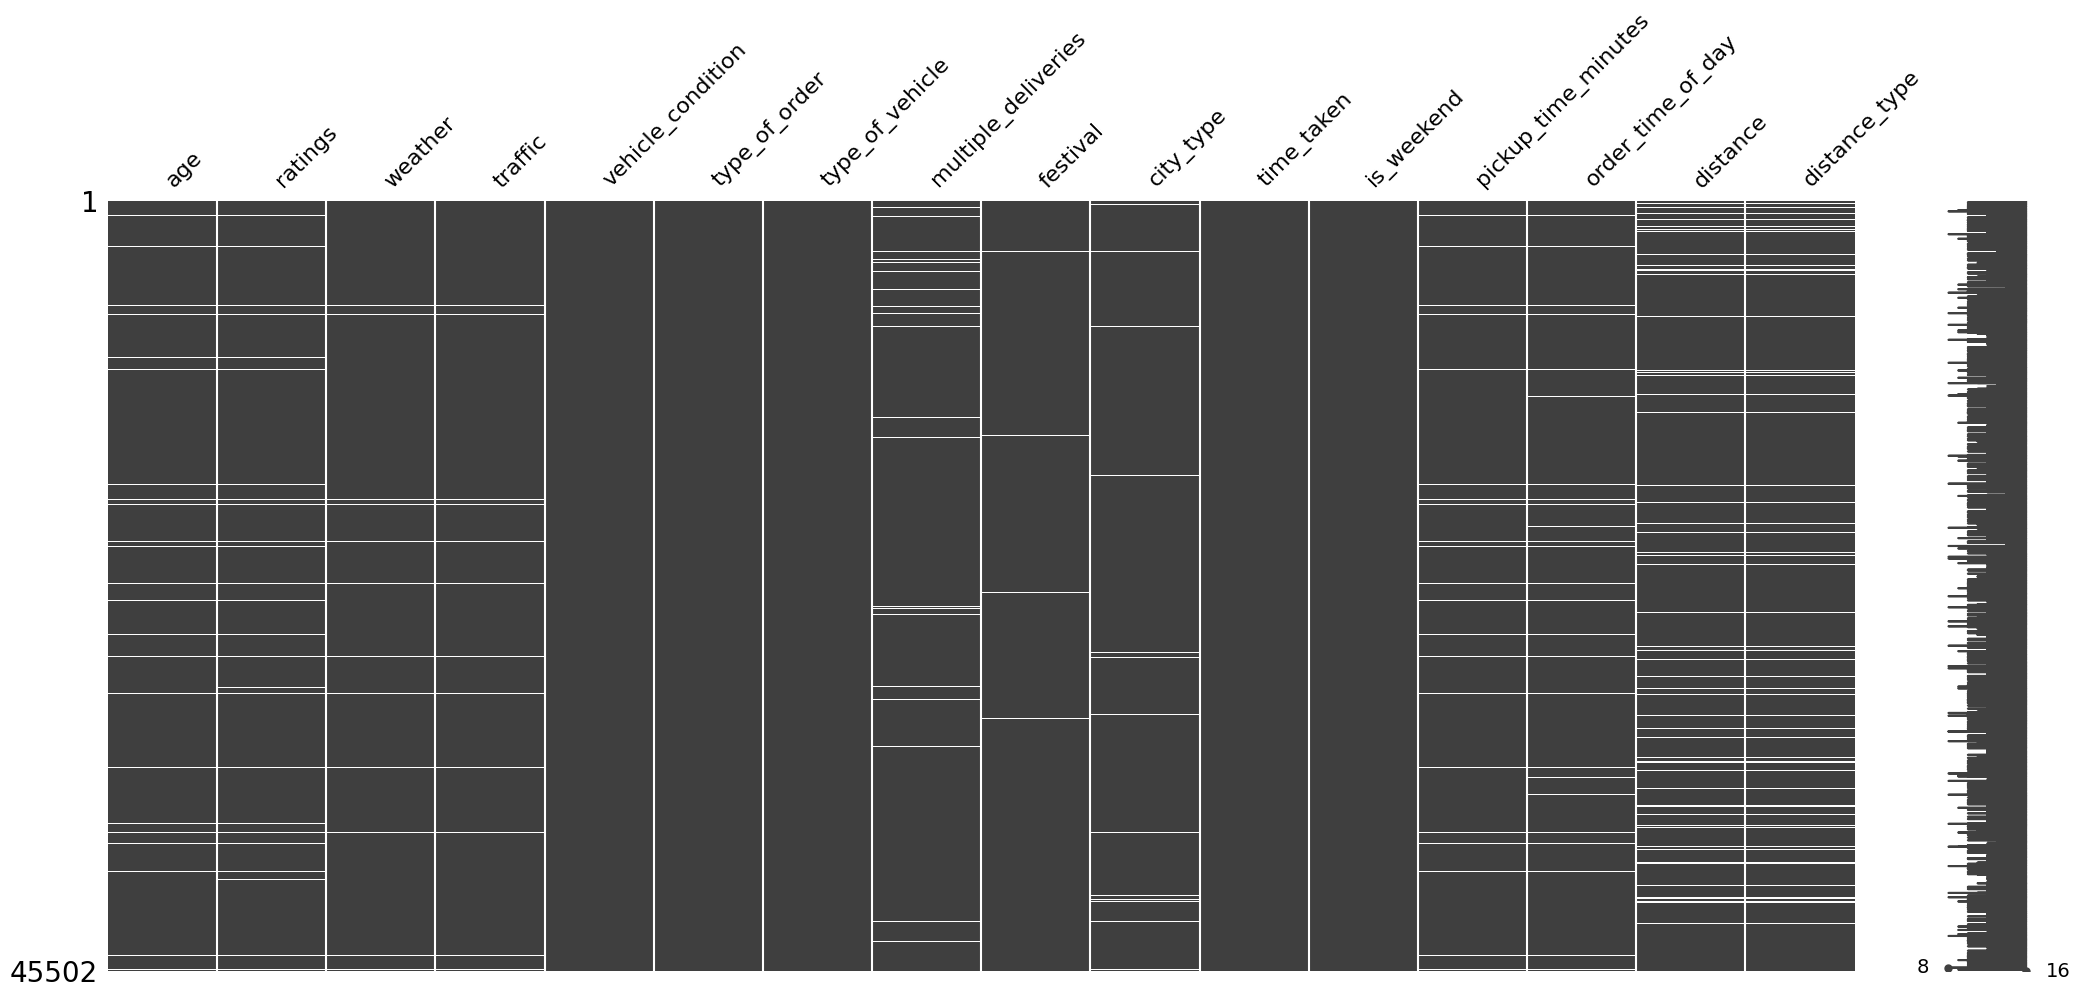

In [99]:
msno.matrix(df)

<Axes: >

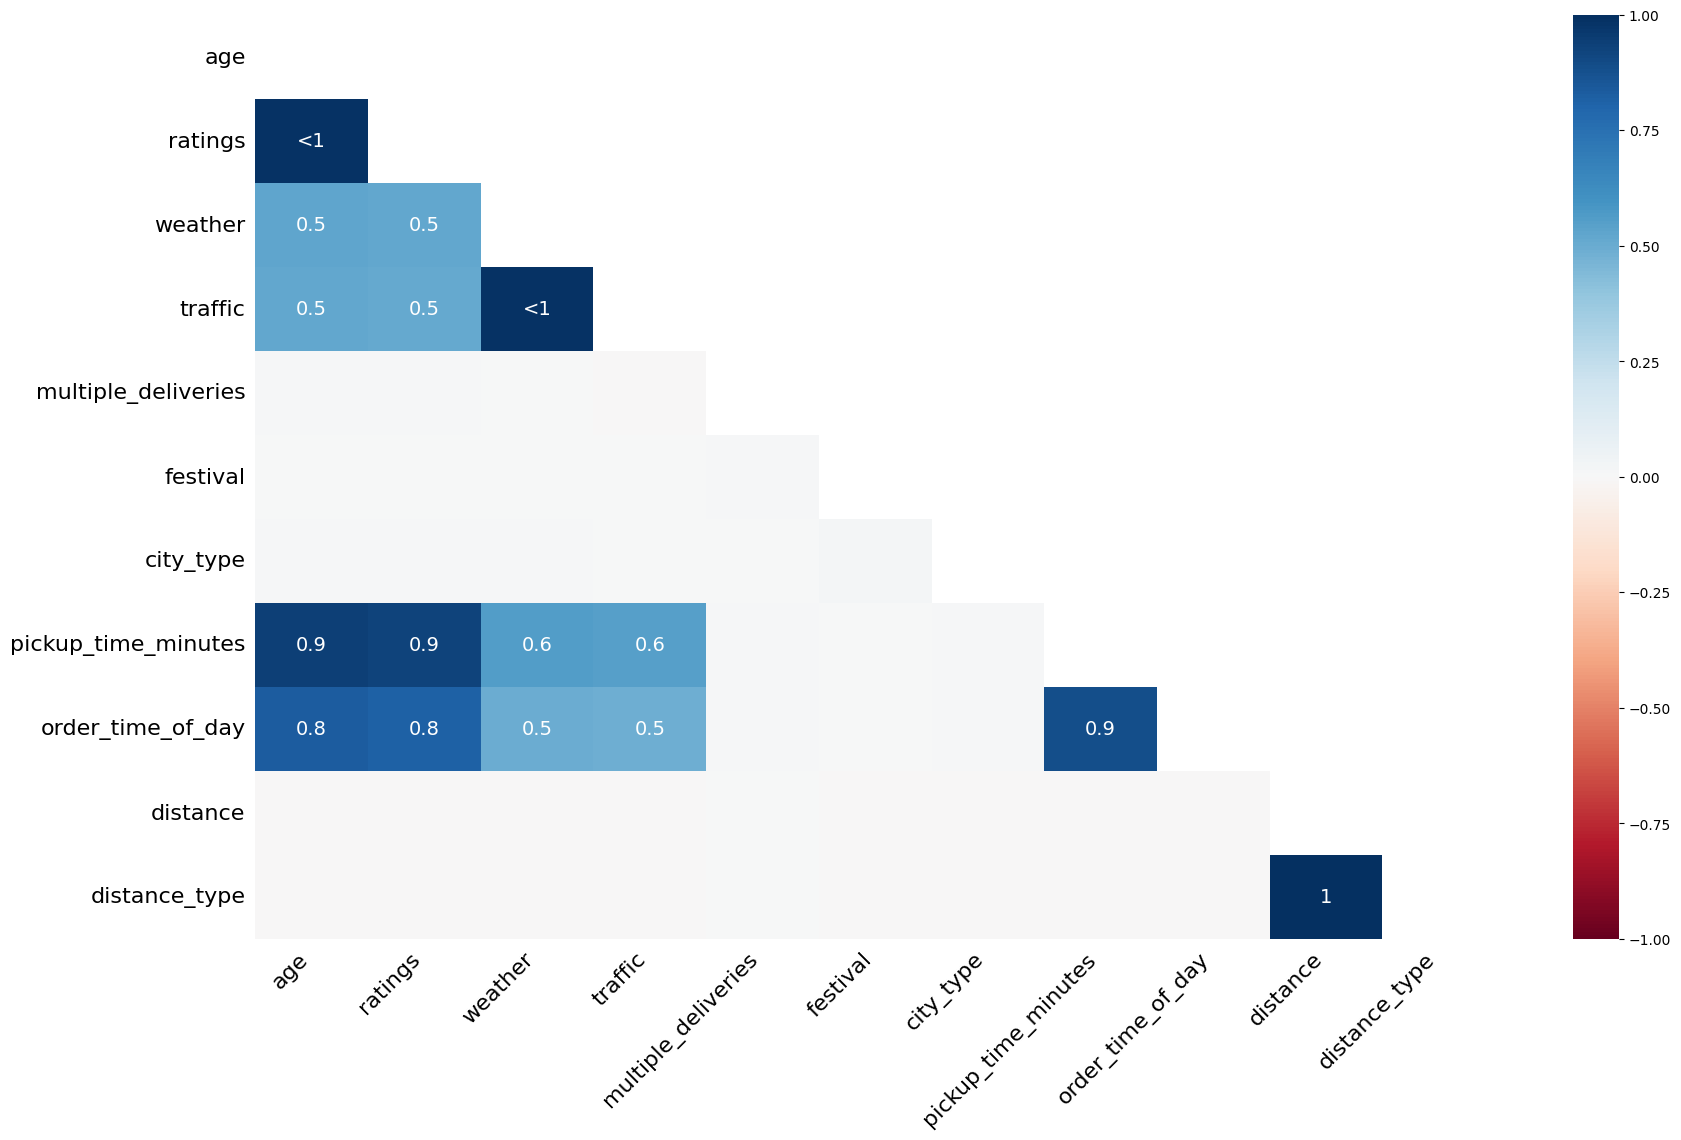

In [100]:
msno.heatmap(df)

# Exp1: Keep vs Drop Missing Values -> With Baseline Model (LR)

# Dropping Missing Values

In [101]:
mlflow.set_tracking_uri("https://dagshub.com/AvanindraBose/Urban-Eats-Food-Delivery-Time-Prediction.mlflow")

In [102]:
mlflow.set_experiment("Exp 1 - Keep vs Drop Missing values with LR Baseline Model")

<Experiment: artifact_location='mlflow-artifacts:/389152c1d15b42dcb8f71c3c1c4e8233', creation_time=1780236545999, experiment_id='1', last_update_time=1780236545999, lifecycle_stage='active', name='Exp 1 - Keep vs Drop Missing values with LR Baseline Model', tags={}, trace_location=None, workspace='default'>

In [103]:
temp_df = df.copy().dropna()

In [104]:
temp_df.isna().sum()

age                    0
ratings                0
weather                0
traffic                0
vehicle_condition      0
type_of_order          0
type_of_vehicle        0
multiple_deliveries    0
festival               0
city_type              0
time_taken             0
is_weekend             0
pickup_time_minutes    0
order_time_of_day      0
distance               0
distance_type          0
dtype: int64

In [105]:
temp_df.shape

(37695, 16)

In [106]:
X = temp_df.drop(columns= ['time_taken'])
y = temp_df['time_taken']

In [107]:
X.sample(10)

,age,ratings,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,is_weekend,pickup_time_minutes,order_time_of_day,distance,distance_type
15710,31.0,3.9,fog,low,1,drinks,motorcycle,1.0,no,metropolitian,0,15.0,night,12.418395,long
15537,36.0,4.3,sandstorms,jam,2,buffet,scooter,1.0,no,metropolitian,1,15.0,night,12.435183,long
37367,26.0,5.0,windy,medium,0,meal,motorcycle,1.0,no,metropolitian,0,5.0,evening,4.471739,short
14312,24.0,4.8,sandstorms,medium,0,drinks,motorcycle,1.0,no,metropolitian,0,15.0,evening,19.916123,very_long
5324,39.0,4.2,sunny,medium,0,drinks,motorcycle,1.0,no,metropolitian,0,10.0,evening,12.435183,long
23620,32.0,4.9,cloudy,jam,0,buffet,motorcycle,2.0,no,metropolitian,1,15.0,night,13.989696,long
13724,38.0,4.9,windy,medium,0,meal,motorcycle,1.0,no,metropolitian,1,5.0,afternoon,19.617929,very_long
10703,32.0,5.0,fog,low,0,drinks,motorcycle,0.0,no,metropolitian,0,10.0,morning,1.544162,short
21330,38.0,4.8,sunny,high,2,buffet,scooter,1.0,no,metropolitian,0,5.0,morning,3.064487,short
7654,30.0,4.9,sandstorms,high,1,snack,scooter,1.0,no,metropolitian,1,15.0,morning,3.025080,short


In [108]:
y.sample(10)

7611     24
44852    26
33151    29
37973    10
33190    22
1067     29
23991    35
2813     32
40966    16
37801    20
Name: time_taken, dtype: int64

In [109]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [110]:
print("The size of train data is",X_train.shape)
print("The shape of test data is",X_test.shape)

The size of train data is (30156, 15)
The shape of test data is (7539, 15)


In [111]:
y_train.to_numpy().reshape(-1,1)

array([[49],
       [31],
       [11],
       ...,
       [15],
       [26],
       [28]], shape=(30156, 1))

__Now Creating Column Transformers for Input Dataset.__

In [114]:
temp_df.columns

Index(['age', 'ratings', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'time_taken', 'is_weekend', 'pickup_time_minutes',
       'order_time_of_day', 'distance', 'distance_type'],
      dtype='object')

In [115]:
temp_df.dtypes

age                    float64
ratings                float64
weather                 object
traffic                 object
vehicle_condition        int64
type_of_order           object
type_of_vehicle         object
multiple_deliveries    float64
festival                object
city_type               object
time_taken               int64
is_weekend               int64
pickup_time_minutes    float64
order_time_of_day       object
distance               float64
distance_type           object
dtype: object

In [116]:
num_cols = X_train.select_dtypes(include=np.number).columns.to_list()

In [117]:
num_cols.remove('vehicle_condition')
num_cols.remove('multiple_deliveries')

In [118]:
num_cols

['age', 'ratings', 'is_weekend', 'pickup_time_minutes', 'distance']

In [119]:
X_train.select_dtypes(include=object).columns.to_list()

['weather',
 'traffic',
 'type_of_order',
 'type_of_vehicle',
 'festival',
 'city_type',
 'order_time_of_day',
 'distance_type']

In [120]:
ordinal_cat_cols = ['traffic','distance_type']

nominal_cat_cols = [
    'weather',
    'type_of_order',
    'type_of_vehicle',
    'festival',
    'city_type',
    'order_time_of_day'
]

In [121]:
len(num_cols + nominal_cat_cols + ordinal_cat_cols)

13

In [122]:
for col in ordinal_cat_cols:
    print(col,X_train[col].unique())

traffic ['jam' 'medium' 'high' 'low']
distance_type ['medium' 'short' 'long' 'very_long']


In [123]:
# generate order for ordinal encoding

traffic_order = ["low","medium","high","jam"]

distance_type_order = ["short","medium","long","very_long"]

In [298]:
preprocessor_dropped = ColumnTransformer(
    transformers=[
        ('numerical columns',MinMaxScaler(),num_cols),
        ('nominal categorical columns',OneHotEncoder(drop='first',handle_unknown='ignore',sparse_output=False),nominal_cat_cols),
        ('ordinal categorical columns', OrdinalEncoder(categories=[traffic_order,distance_type_order]),ordinal_cat_cols)
    ],remainder='passthrough',n_jobs=-1,force_int_remainder_cols=False,verbose_feature_names_out=False
)

In [ ]:
X_train_trans = preprocessor_dropped.fit_transform(X_train)
X_test_trans = preprocessor_dropped.transform(X_test)

X_train_trans

c:\Users\avanindra Bose\Urban Eats Delivery Time Prediction\UrbanEats-Delivery-Time-Prediction\.venv\Lib\site-packages\sklearn\compose\_column_transformer.py:978: FutureWarning: The parameter `force_int_remainder_cols` is deprecated and will be removed in 1.9. It has no effect. Leave it to its default value to avoid this warning.
  warnings.warn(


,age,ratings,is_weekend,pickup_time_minutes,distance,weather_fog,weather_sandstorms,weather_stormy,weather_sunny,weather_windy,...,festival_yes,city_type_semi-urban,city_type_urban,order_time_of_day_evening,order_time_of_day_morning,order_time_of_day_night,traffic,distance_type,vehicle_condition,multiple_deliveries
8708,0.473684,0.56,0.0,1.0,0.404165,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,3.0,1.0,0,2.0
25198,1.000000,0.76,1.0,0.0,0.154044,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,1.0
34049,0.473684,0.80,0.0,0.5,0.002461,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,2.0,0.0,1,0.0
25987,1.000000,0.92,1.0,1.0,0.460411,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,0,1.0
37121,0.526316,0.76,1.0,0.5,0.243676,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20239,0.578947,0.92,1.0,0.5,0.451895,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,3.0,2.0,0,0.0
7590,0.052632,1.00,1.0,1.0,0.612270,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,2.0,1,1.0
13610,0.526316,0.92,1.0,0.0,0.322877,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1,0.0
1045,0.947368,0.96,1.0,0.5,0.004486,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0,1.0


In [ ]:
preprocessor_dropped = ColumnTransformer(
    transformers=[
        ('numerical columns',MinMaxScaler(),num_cols),
        ('nominal categorical columns',OneHotEncoder(drop='first',handle_unknown='ignore',sparse_output=False),nominal_cat_cols),
        ('ordinal categorical columns', OrdinalEncoder(categories=[traffic_order,distance_type_order]),ordinal_cat_cols)
    ],remainder='passthrough',n_jobs=-1,force_int_remainder_cols=False,verbose_feature_names_out=False
)

baseline_pipeline = Pipeline(
    steps=[
        ('preprocessor',preprocessor_dropped),
        ('model',LinearRegression())
    ]
)

model = TransformedTargetRegressor(
    regressor = baseline_pipeline,
    transformer = PowerTransformer()    
)

In [135]:
model.fit(X_train,y_train)

c:\Users\avanindra Bose\Urban Eats Delivery Time Prediction\UrbanEats-Delivery-Time-Prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but PowerTransformer was fitted without feature names
  warnings.warn(
c:\Users\avanindra Bose\Urban Eats Delivery Time Prediction\UrbanEats-Delivery-Time-Prediction\.venv\Lib\site-packages\sklearn\compose\_column_transformer.py:978: FutureWarning: The parameter `force_int_remainder_cols` is deprecated and will be removed in 1.9. It has no effect. Leave it to its default value to avoid this warning.
  warnings.warn(


,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.",Pipeline(step...egression())])
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",PowerTransformer()
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",None
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",None
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical columns', ...), ('nominal categorical columns', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to a

In [136]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

In [137]:
print(f"The train error is {mean_absolute_error(y_train,y_pred_train):.2f} minutes")
print(f"The test error is {mean_absolute_error(y_test,y_pred_test):.2f} minutes")

The train error is 4.71 minutes
The test error is 4.69 minutes


In [138]:
print(f"The train r2 score is {r2_score(y_train,y_pred_train):.2f}")
print(f"The test r2 score is {r2_score(y_test,y_pred_test):.2f}")

The train r2 score is 0.60
The test r2 score is 0.60


In [139]:
scores = cross_val_score(model,X_train,y_train,cv=5,scoring="r2",n_jobs=-1)

scores

array([0.59412549, 0.59710262, 0.60215011, 0.59679701, 0.60837436])

In [141]:
with mlflow.start_run(run_name='Drop Missing Values'):
    mlflow.log_param("experiment_type","Drop Missing Values")
    mlflow.log_param("model_type","LinearRegression")
    mlflow.log_params(model.get_params())

    # log metrics
    mlflow.log_metric("training_error",mean_absolute_error(y_train,y_pred_train))
    mlflow.log_metric("test_error",mean_absolute_error(y_test,y_pred_test))
    mlflow.log_metric("training_r2",r2_score(y_train,y_pred_train))
    mlflow.log_metric("test_r2",r2_score(y_test,y_pred_test))
    mlflow.log_metric("cross_val_r2",scores.mean())



🏃 View run Drop Missing Values at: https://dagshub.com/AvanindraBose/Urban-Eats-Food-Delivery-Time-Prediction.mlflow/#/experiments/1/runs/e1f08a79e41341dfb992b11b7e74b404
🧪 View experiment at: https://dagshub.com/AvanindraBose/Urban-Eats-Food-Delivery-Time-Prediction.mlflow/#/experiments/1


# Imputing Missing Values

In [142]:
missing_df = df.copy()

In [143]:
missing_df.isna().sum()

age                    1854
ratings                1908
weather                 525
traffic                 510
vehicle_condition         0
type_of_order             0
type_of_vehicle           0
multiple_deliveries     993
festival                228
city_type              1198
time_taken                0
is_weekend                0
pickup_time_minutes    1640
order_time_of_day      2070
distance               3630
distance_type          3630
dtype: int64

In [144]:
missing_df.shape

(45502, 16)

In [148]:
X = missing_df.drop(columns=['time_taken'])
y = missing_df['time_taken']

In [149]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state=42)

In [150]:
X_train.shape

(36401, 15)

In [151]:
X_test.shape

(9101, 15)

In [167]:
missing_cols = X_train.columns[X_train.isna().any(axis=0)]

In [168]:
missing_cols

Index(['age', 'ratings', 'weather', 'traffic', 'multiple_deliveries',
       'festival', 'city_type', 'pickup_time_minutes', 'order_time_of_day',
       'distance', 'distance_type'],
      dtype='object')

In [173]:
def percent_missing(col):
    return round((X_train[col].isna().sum() / X_train.shape[0])* 100,2)

# age

In [174]:
percent_missing('age')

np.float64(4.04)

In [175]:
X_train['age'].describe()

count    34931.000000
mean        29.569551
std          5.752869
min         20.000000
25%         25.000000
50%         30.000000
75%         35.000000
max         39.000000
Name: age, dtype: float64

In [176]:
age_median = X_train['age'].median()

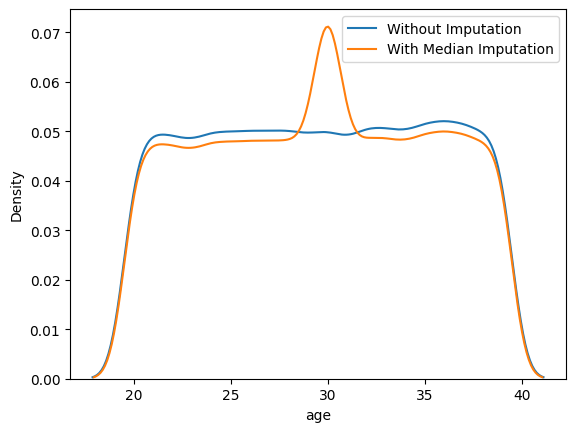

In [180]:
sns.kdeplot(X_train['age'],label='Without Imputation')
sns.kdeplot(X_train['age'].fillna(age_median),label='With Median Imputation')

plt.legend()

__Observation:__

Changed the distribution of the age column.

Use Advanced imputation techniques like KNN imputer.

# rating


In [184]:
percent_missing('ratings')

np.float64(4.15)

In [185]:
X_train['ratings'].describe()

count    34891.000000
mean         4.635058
std          0.314049
min          2.500000
25%          4.500000
50%          4.700000
75%          4.900000
max          5.000000
Name: ratings, dtype: float64

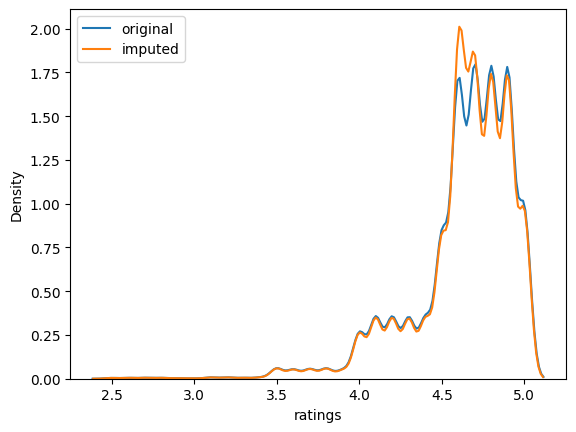

In [186]:
sns.kdeplot(X_train['ratings'],label="original")
sns.kdeplot(X_train['ratings'].fillna(X_train['ratings'].mean()),label="imputed")
plt.legend()

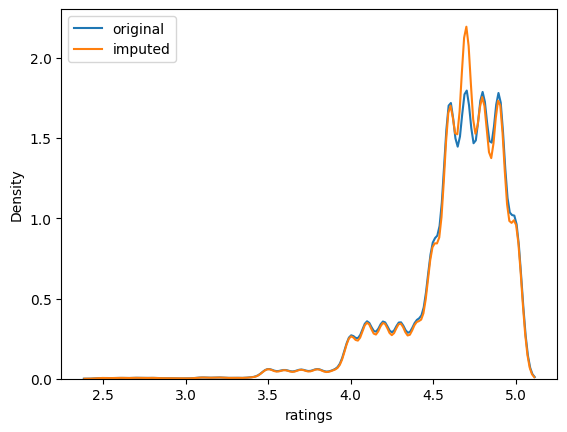

In [187]:
sns.kdeplot(X_train['ratings'],label="original")
sns.kdeplot(X_train['ratings'].fillna(X_train['ratings'].median()),label="imputed")
plt.legend()

__Observations__

1. The distribution is getting slightly changed. Maybe I can try both ways Imputing using KNN and Imputing using median.

In [188]:
missing_cols

Index(['age', 'ratings', 'weather', 'traffic', 'multiple_deliveries',
       'festival', 'city_type', 'pickup_time_minutes', 'order_time_of_day',
       'distance', 'distance_type'],
      dtype='object')

# weather

In [190]:
X_train['weather'].value_counts(dropna=False)

weather
fog           6160
stormy        6051
cloudy        6033
sandstorms    5958
windy         5928
sunny         5850
NaN            421
Name: count, dtype: int64

In [191]:
percent_missing('weather')

np.float64(1.16)

<Axes: xlabel='weather', ylabel='count'>

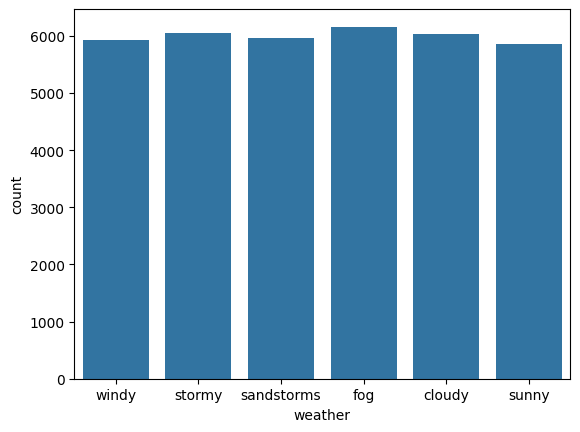

In [192]:
sns.countplot(x=X_train['weather'])

__Observations__

1. There is no such distinct category which has majority count. 
2. All the categories are nearly equal in counts. If imputed using mode one category can exceed which will again change the distribution.
3. Need to Infer Advanced Imputation Technique.

# traffic

In [193]:
X_train['traffic'].value_counts(dropna=False)

traffic
low       12323
jam       11320
medium     8773
high       3578
NaN         407
Name: count, dtype: int64

In [195]:
percent_missing('traffic')

np.float64(1.12)

<Axes: xlabel='traffic', ylabel='count'>

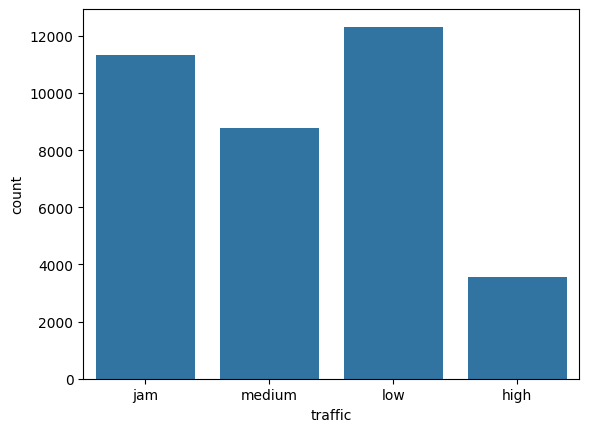

In [196]:
sns.countplot(x=X_train['traffic'])

__Observations__

1. No Dominant Category.

2. Low seems to be the highest category among all.But Imputing from mode will change the distirbution.

# Multiple Deliveries

In [198]:
X_train['multiple_deliveries'].value_counts(dropna=False)

multiple_deliveries
1.0    22487
0.0    11252
2.0     1599
NaN      795
3.0      268
Name: count, dtype: int64

In [199]:
percent_missing('multiple_deliveries')

np.float64(2.18)

<Axes: xlabel='multiple_deliveries', ylabel='count'>

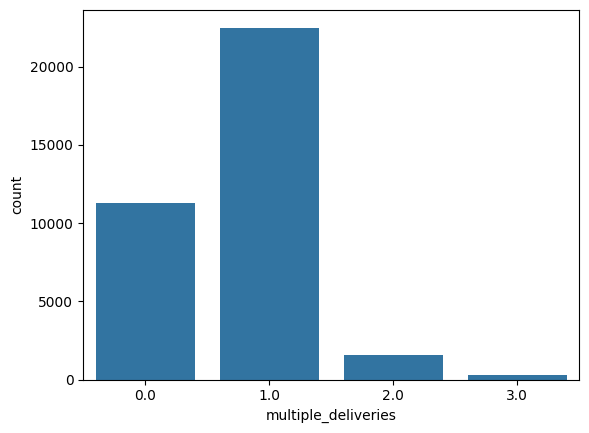

In [200]:
sns.countplot(x='multiple_deliveries',data=X_train)

In [210]:
md_mode = X_train['multiple_deliveries'].mode()[0]

In [211]:
X_train['multiple_deliveries'].fillna(md_mode).value_counts(dropna=False)

multiple_deliveries
1.0    23282
0.0    11252
2.0     1599
3.0      268
Name: count, dtype: int64

<Axes: xlabel='multiple_deliveries', ylabel='count'>

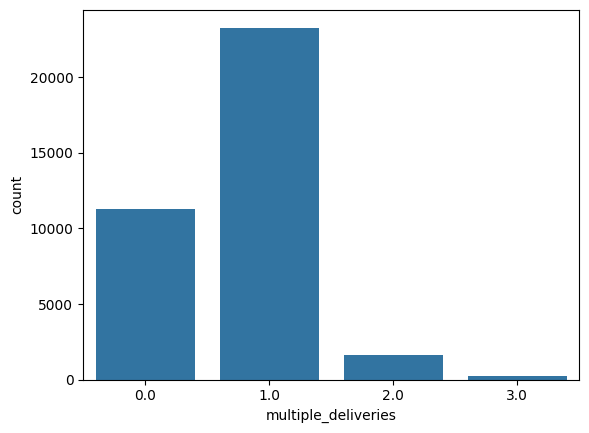

In [212]:
sns.countplot(x = X_train['multiple_deliveries'].fillna(md_mode))

__Observations__

1. Since I have a dominant category of 1 hence I'm imputing from mode itself.

# festival

In [217]:
X_train['festival'].value_counts(dropna=False)

festival
no     35474
yes      739
NaN      188
Name: count, dtype: int64

In [218]:
percent_missing('festival')

np.float64(0.52)

<Axes: xlabel='festival', ylabel='count'>

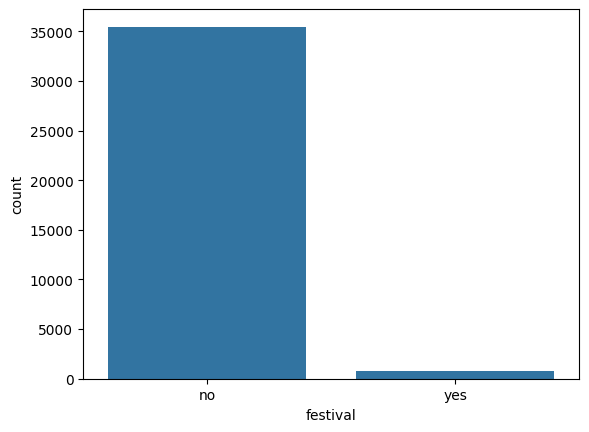

In [219]:
sns.countplot(x = X_train['festival'])

In [223]:
mode_ft = X_train['festival'].mode()[0]

In [224]:
X_train['festival'].fillna(mode_ft).value_counts(dropna=False)

festival
no     35662
yes      739
Name: count, dtype: int64

<Axes: xlabel='festival', ylabel='count'>

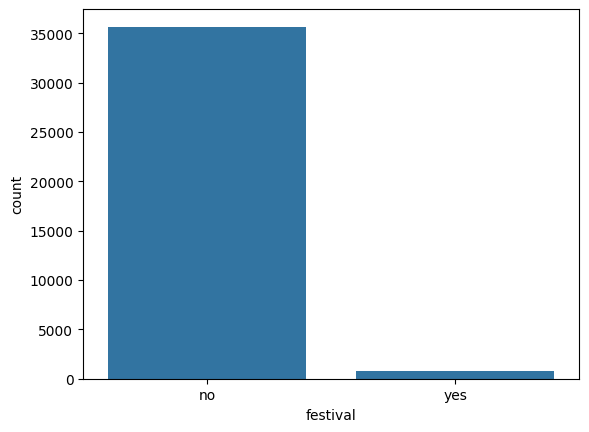

In [225]:
sns.countplot(x = X_train['festival'].fillna(mode_ft))

__Observation__

1. We can impute festival column with mode.

# city_type

In [228]:
X_train['city_type'].value_counts(dropna=False)

city_type
metropolitian    27245
urban             8058
NaN                968
semi-urban         130
Name: count, dtype: int64

In [231]:
percent_missing('city_type')

np.float64(2.66)

<Axes: xlabel='city_type', ylabel='count'>

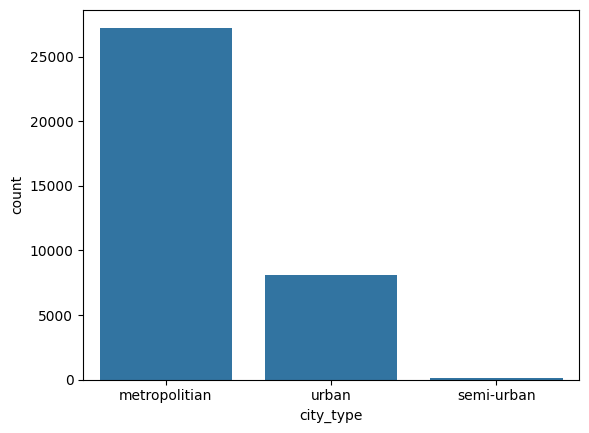

In [229]:
sns.countplot(x = X_train['city_type'])

In [230]:
mode_ct = X_train['city_type'].mode()[0]

In [232]:
X_train['city_type'].fillna(mode_ct).value_counts(dropna=False)

city_type
metropolitian    28213
urban             8058
semi-urban         130
Name: count, dtype: int64

<Axes: xlabel='city_type', ylabel='count'>

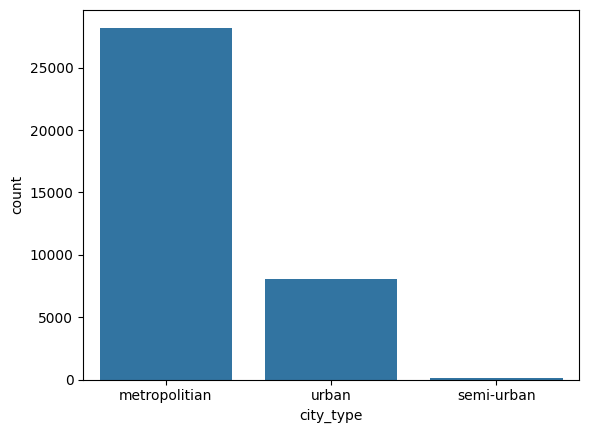

In [233]:
sns.countplot(x = X_train['city_type'].fillna(mode_ct))

__Observations__

1. Imputed city_type column with majority category.

In [234]:
missing_cols

Index(['age', 'ratings', 'weather', 'traffic', 'multiple_deliveries',
       'festival', 'city_type', 'pickup_time_minutes', 'order_time_of_day',
       'distance', 'distance_type'],
      dtype='object')

# pickup_time_minutes

In [235]:
X_train['pickup_time_minutes'].value_counts(dropna=False)

pickup_time_minutes
10.0    11704
5.0     11704
15.0    11695
NaN      1298
Name: count, dtype: int64

In [237]:
percent_missing('pickup_time_minutes')

np.float64(3.57)

In [238]:
X_train['pickup_time_minutes'].describe()

count    35103.000000
mean         9.998718
std          4.082279
min          5.000000
25%          5.000000
50%         10.000000
75%         15.000000
max         15.000000
Name: pickup_time_minutes, dtype: float64

In [239]:
pickup_time_minutes_median = X_train['pickup_time_minutes'].median()

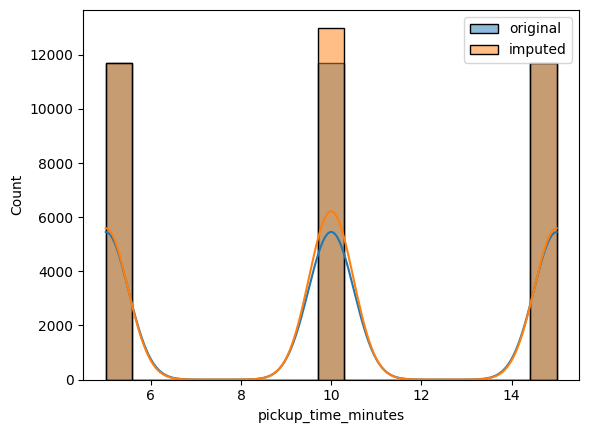

In [240]:
sns.histplot(X_train['pickup_time_minutes'],kde=True,label='original')
sns.histplot(X_train['pickup_time_minutes'].fillna(pickup_time_minutes_median),kde=True,label='imputed')
plt.legend()

__Observations__

1. The distirbution is distorted. Hence I need to use advcne  techniques.

# Order time of day

In [241]:
X_train['order_time_of_day'].value_counts(dropna=False)

order_time_of_day
night        10994
evening      10906
morning       6883
afternoon     5972
NaN           1646
Name: count, dtype: int64

In [242]:
percent_missing('order_time_of_day')

np.float64(4.52)

<Axes: xlabel='count', ylabel='order_time_of_day'>

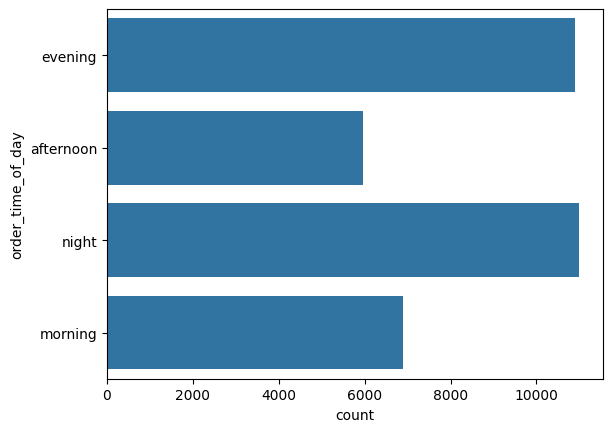

In [243]:
sns.countplot(X_train['order_time_of_day'])

In [244]:
X_train[X_train['order_time_of_day'].isna()]

,age,ratings,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,is_weekend,pickup_time_minutes,order_time_of_day,distance,distance_type
14475,NaN,NaN,stormy,low,2,meal,scooter,1.0,no,metropolitian,1,NaN,NaN,1.554563,short
21916,20.0,2.8,sunny,low,2,drinks,scooter,1.0,no,metropolitian,0,10.0,NaN,10.427236,long
34951,28.0,5.0,fog,low,2,snack,motorcycle,1.0,no,metropolitian,1,15.0,NaN,16.903757,very_long
8165,NaN,NaN,NaN,NaN,3,meal,scooter,1.0,no,metropolitian,0,NaN,NaN,19.673431,very_long
23469,NaN,NaN,sunny,jam,0,buffet,motorcycle,1.0,no,metropolitian,0,NaN,NaN,4.674220,short
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33827,NaN,NaN,NaN,NaN,3,drinks,electric_scooter,1.0,no,urban,0,NaN,NaN,NaN,NaN
22403,NaN,NaN,sunny,low,0,snack,motorcycle,1.0,no,urban,0,NaN,NaN,3.024981,short
21518,NaN,NaN,stormy,jam,1,meal,scooter,0.0,no,urban,1,NaN,NaN,17.097973,very_long
22002,25.0,5.0,sunny,low,1,meal,scooter,1.0,no,metropolitian,0,5.0,NaN,8.789430,medium


__Observation__

1. No Mode Imputation Technique.

# distance

In [245]:
X_train['distance'].describe()

count    33470.000000
mean         9.738154
std          5.608401
min          1.465067
25%          4.657672
50%          9.193421
75%         13.681057
max         20.969489
Name: distance, dtype: float64

In [246]:
percent_missing('distance')

np.float64(8.05)

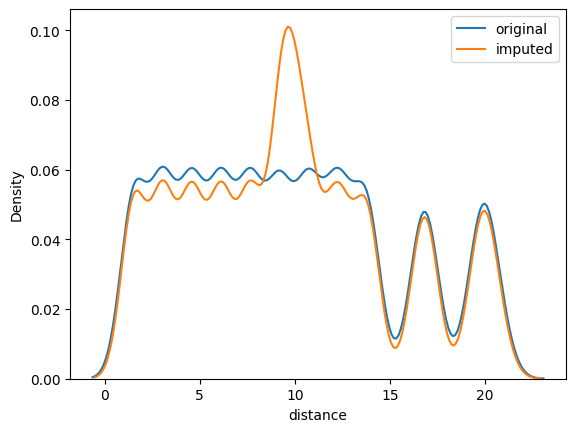

In [247]:
sns.kdeplot(X_train['distance'],label='original')
sns.kdeplot(X_train['distance'].fillna(X_train['distance'].mean()),label='imputed')
plt.legend()

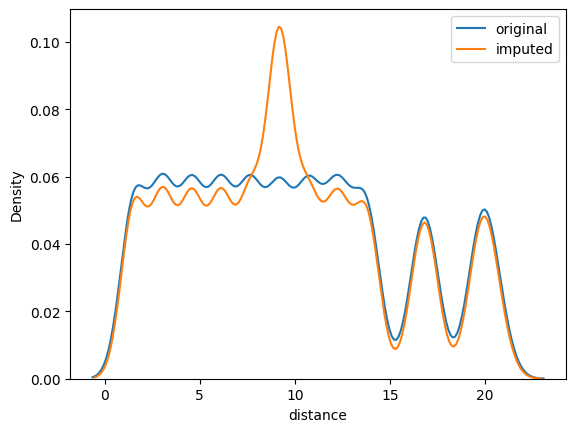

In [248]:
sns.kdeplot(X_train['distance'],label='original')
sns.kdeplot(X_train['distance'].fillna(X_train['distance'].median()),label='imputed')
plt.legend()

__Observation__

1. Clearly the distribution is changing, hence I need to use advance imputation technique.

# distance_type

In [249]:
X_train['distance_type'].value_counts(dropna=False)

distance_type
long         9025
short        8998
medium       8993
very_long    6454
NaN          2931
Name: count, dtype: int64

In [250]:
percent_missing('distance_type')

np.float64(8.05)

<Axes: xlabel='distance_type', ylabel='count'>

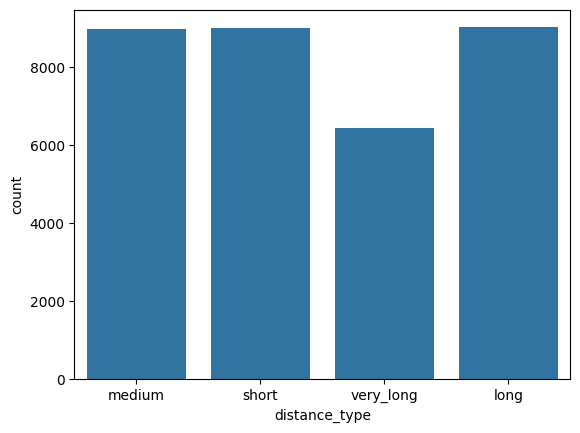

In [251]:
sns.countplot(x = X_train['distance_type'])

__Observation__

1. No Majority Category. Hence it cannot be imputed by mode.

# Imputation Pipeline

In [252]:
missing_cols

Index(['age', 'ratings', 'weather', 'traffic', 'multiple_deliveries',
       'festival', 'city_type', 'pickup_time_minutes', 'order_time_of_day',
       'distance', 'distance_type'],
      dtype='object')

In [254]:
num_cols

['age', 'ratings', 'is_weekend', 'pickup_time_minutes', 'distance']

In [259]:
nominal_cat_cols

['weather',
 'type_of_order',
 'type_of_vehicle',
 'festival',
 'city_type',
 'order_time_of_day']

In [260]:
ordinal_cat_cols

['traffic', 'distance_type']

In [261]:
len(num_cols + nominal_cat_cols + ordinal_cat_cols)

13

In [264]:
features_to_fill_mode = ['multiple_deliveries','festival','city_type']
features_to_fill_missing = [col for col in nominal_cat_cols if col not in features_to_fill_mode]

In [265]:
features_to_fill_missing

['weather', 'type_of_order', 'type_of_vehicle', 'order_time_of_day']

In [276]:
simple_imputer = ColumnTransformer(
    transformers=[
        ('mode_imputer',SimpleImputer(strategy='most_frequent'),features_to_fill_mode),
        ('missing_imputer',SimpleImputer(strategy='constant',fill_value='missing'),features_to_fill_missing)
    ],remainder = 'passthrough',n_jobs=-1,force_int_remainder_cols=False,verbose_feature_names_out=False
)

simple_imputer

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('mode_imputer', ...), ('missing_imputer', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",-1
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` an

In [277]:
knn_imputer = KNNImputer(n_neighbors=5)

__Creating a Pipeline Now.__

In [278]:
preprocessor = ColumnTransformer(transformers=[
    ("scale", MinMaxScaler(), num_cols),
    ("nominal_encode", OneHotEncoder(drop="first",handle_unknown="ignore",
                                     sparse_output=False), nominal_cat_cols),
    ("ordinal_encode", OrdinalEncoder(categories=[traffic_order,distance_type_order],
                                      encoded_missing_value=-999,
                                      handle_unknown="use_encoded_value",
                                      unknown_value=-1), ordinal_cat_cols)
],remainder="passthrough",n_jobs=-1,force_int_remainder_cols=False,verbose_feature_names_out=False)

In [279]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scale', ...), ('nominal_encode', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",-1
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and `

In [285]:
preprocessing_pipeline = Pipeline(
    steps=[
        ('imputer',simple_imputer),
        ('preprocessor',preprocessor),
        ('knn imputer',knn_imputer)
    ]
)

In [286]:
preprocessing_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('mode_imputer', ...), ('missing_imputer', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the outp

In [289]:
model_pipeline = TransformedTargetRegressor(
    regressor = Pipeline(
        steps = [
            ('preprocessing', preprocessing_pipeline),
            ('model',LinearRegression())
        ]
    ),
    transformer = PowerTransformer()
)

In [290]:
model_pipeline.fit(X_train,y_train)

c:\Users\avanindra Bose\Urban Eats Delivery Time Prediction\UrbanEats-Delivery-Time-Prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but PowerTransformer was fitted without feature names
  warnings.warn(
c:\Users\avanindra Bose\Urban Eats Delivery Time Prediction\UrbanEats-Delivery-Time-Prediction\.venv\Lib\site-packages\sklearn\compose\_column_transformer.py:978: FutureWarning: The parameter `force_int_remainder_cols` is deprecated and will be removed in 1.9. It has no effect. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\avanindra Bose\Urban Eats Delivery Time Prediction\UrbanEats-Delivery-Time-Prediction\.venv\Lib\site-packages\sklearn\compose\_column_transformer.py:978: FutureWarning: The parameter `force_int_remainder_cols` is deprecated and will be removed in 1.9. It has no effect. Leave it to its default value to avoid this warning.
  warnings.warn(


,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.",Pipeline(step...egression())])
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",PowerTransformer()
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",None
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",None
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pa

In [291]:
y_pred_train = model_pipeline.predict(X_train)
y_pred_test = model_pipeline.predict(X_test)

In [292]:
print(f"The train error is {mean_absolute_error(y_train,y_pred_train):.2f} minutes")
print(f"The test error is {mean_absolute_error(y_test,y_pred_test):.2f} minutes")

The train error is 4.84 minutes
The test error is 4.86 minutes


In [293]:
print(f"The train r2 score is {r2_score(y_train,y_pred_train):.2f}")
print(f"The test r2 score is {r2_score(y_test,y_pred_test):.2f}")

The train r2 score is 0.58
The test r2 score is 0.57


In [294]:
scores = cross_val_score(
    model_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

In [295]:
scores

array([0.58325997, 0.57736844, 0.58794404, 0.56879662, 0.57332788])

In [296]:
with mlflow.start_run(run_name="Imputed Missing Values"):
    mlflow.log_param("experiment_type","Imputed Missing Values")
    mlflow.log_param("model_type","LinearRegression")
    mlflow.log_params(model_pipeline.get_params())
    mlflow.log_metric("training_error",mean_absolute_error(y_train,y_pred_train))
    mlflow.log_metric("test_error",mean_absolute_error(y_test,y_pred_test))
    mlflow.log_metric("training_r2",r2_score(y_train,y_pred_train))
    mlflow.log_metric("test_r2",r2_score(y_test,y_pred_test))
    mlflow.log_metric("cross_val_r2",scores.mean())

🏃 View run Imputed Missing Values at: https://dagshub.com/AvanindraBose/Urban-Eats-Food-Delivery-Time-Prediction.mlflow/#/experiments/1/runs/80bb755513344a31a34a0df9b9df212f
🧪 View experiment at: https://dagshub.com/AvanindraBose/Urban-Eats-Food-Delivery-Time-Prediction.mlflow/#/experiments/1


# Even After Imputing Missing Values Carefully The errors increased and r2 score decreased. Hence Dropping the Missing Comes to to be a better Approach

# Trying a Different Baseline Model -> Random Forest

In [300]:
dropped_df = df.copy().dropna()

In [301]:
X_dropped = dropped_df.drop(columns='time_taken')
y_dropped = dropped_df['time_taken']

In [302]:
X_train_dropped,X_test_dropped,y_train_dropped,y_test_dropped = train_test_split(X_dropped,y_dropped,test_size=0.2,random_state=42)

In [303]:
preprocessor_dropped = ColumnTransformer(
    transformers=[
        ('numerical columns',MinMaxScaler(),num_cols),
        ('nominal categorical columns',OneHotEncoder(drop='first',handle_unknown='ignore',sparse_output=False),nominal_cat_cols),
        ('ordinal categorical columns', OrdinalEncoder(categories=[traffic_order,distance_type_order]),ordinal_cat_cols)
    ],remainder='passthrough',n_jobs=-1,force_int_remainder_cols=False,verbose_feature_names_out=False
)

baseline_pipeline_dropped = Pipeline(
    steps=[
        ('preprocessor',preprocessor_dropped),
        ('model',RandomForestRegressor(random_state=42))
    ]
)

model_pipe_dropped = TransformedTargetRegressor(
    regressor = baseline_pipeline_dropped,
    transformer = PowerTransformer()    
)

In [305]:
model_pipe_dropped.fit(X_train_dropped,y_train_dropped)

c:\Users\avanindra Bose\Urban Eats Delivery Time Prediction\UrbanEats-Delivery-Time-Prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but PowerTransformer was fitted without feature names
  warnings.warn(
c:\Users\avanindra Bose\Urban Eats Delivery Time Prediction\UrbanEats-Delivery-Time-Prediction\.venv\Lib\site-packages\sklearn\compose\_column_transformer.py:978: FutureWarning: The parameter `force_int_remainder_cols` is deprecated and will be removed in 1.9. It has no effect. Leave it to its default value to avoid this warning.
  warnings.warn(


,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.",Pipeline(step...m_state=42))])
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",PowerTransformer()
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",None
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",None
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical columns', ...), ('nominal categorical columns', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to a

In [307]:
y_pred_train_dropped = model_pipe_dropped.predict(X_train_dropped)
y_pred_test_dropped = model_pipe_dropped.predict(X_test_dropped)

print(f"The train error is {mean_absolute_error(y_train_dropped,y_pred_train_dropped):.2f} minutes")
print(f"The test error is {mean_absolute_error(y_test_dropped,y_pred_test_dropped):.2f} minutes")

print(f"The train r2 score is {r2_score(y_train_dropped,y_pred_train_dropped):.2f}")
print(f"The test r2 score is {r2_score(y_test_dropped,y_pred_test_dropped):.2f}")

scores_dropped = cross_val_score(
    model_pipe_dropped,
    X_train_dropped,
    y_train_dropped,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

print("Cross validated r2 scores for dropped missing values are",scores_dropped)

The train error is 1.16 minutes
The test error is 3.10 minutes
The train r2 score is 0.98
The test r2 score is 0.83
Cross validated r2 scores for dropped missing values are [0.82461643 0.8266513  0.82691264 0.82564512 0.82780124]


__Imputation Pipeline__

In [308]:
imputed_df = df.copy()

In [310]:
X_imputed = imputed_df.drop(columns='time_taken')
y_imputed = imputed_df['time_taken']

In [311]:
X_train_imputed,X_test_imputed,y_train_imputed,y_test_imputed = train_test_split(X_imputed,y_imputed,test_size=0.2,random_state=42)

In [315]:
preprocessor_imputed = ColumnTransformer(transformers=[
    ("scale", MinMaxScaler(), num_cols),
    ("nominal_encode", OneHotEncoder(drop="first",handle_unknown="ignore",
                                     sparse_output=False), nominal_cat_cols),
    ("ordinal_encode", OrdinalEncoder(categories=[traffic_order,distance_type_order],
                                      encoded_missing_value=-999,
                                      handle_unknown="use_encoded_value",
                                      unknown_value=-1), ordinal_cat_cols)
],remainder="passthrough",n_jobs=-1,force_int_remainder_cols=False,verbose_feature_names_out=False)

preprocessing_pipeline_imputed = Pipeline(
    steps=[
        ('imputer',simple_imputer),
        ('preprocessor',preprocessor_imputed),
        ('knn imputer',knn_imputer)
    ]
)

model_pipe_imputed = TransformedTargetRegressor(
    regressor = Pipeline(
        steps = [
            ('preprocessing', preprocessing_pipeline_imputed),
            ('model',RandomForestRegressor(random_state=42))
        ]
    ),
    transformer = PowerTransformer()
)

In [317]:
model_pipe_imputed.fit(X_train_imputed , y_train_imputed)

c:\Users\avanindra Bose\Urban Eats Delivery Time Prediction\UrbanEats-Delivery-Time-Prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but PowerTransformer was fitted without feature names
  warnings.warn(
c:\Users\avanindra Bose\Urban Eats Delivery Time Prediction\UrbanEats-Delivery-Time-Prediction\.venv\Lib\site-packages\sklearn\compose\_column_transformer.py:978: FutureWarning: The parameter `force_int_remainder_cols` is deprecated and will be removed in 1.9. It has no effect. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\avanindra Bose\Urban Eats Delivery Time Prediction\UrbanEats-Delivery-Time-Prediction\.venv\Lib\site-packages\sklearn\compose\_column_transformer.py:978: FutureWarning: The parameter `force_int_remainder_cols` is deprecated and will be removed in 1.9. It has no effect. Leave it to its default value to avoid this warning.
  warnings.warn(


,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.",Pipeline(step...m_state=42))])
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",PowerTransformer()
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",None
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",None
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pa

In [319]:
y_pred_train_imputed = model_pipe_imputed.predict(X_train_imputed)
y_pred_test_imputed = model_pipe_imputed.predict(X_test_imputed)

print(f"The train error is {mean_absolute_error(y_train_imputed,y_pred_train_imputed):.2f} minutes")
print(f"The test error is {mean_absolute_error(y_test_imputed,y_pred_test_imputed):.2f} minutes")

print(f"The train r2 score is {r2_score(y_train_imputed,y_pred_train_imputed):.2f}")
print(f"The test r2 score is {r2_score(y_test_imputed,y_pred_test_imputed):.2f}")

scores_imputed = cross_val_score(
    model_pipe_imputed,
    X_train_imputed,
    y_train_imputed,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

print("Cross validated r2 scores after imputing missing values are",scores_dropped)

The train error is 1.22 minutes
The test error is 3.30 minutes
The train r2 score is 0.97
The test r2 score is 0.80
Cross validated r2 scores after imputing missing values are [0.82461643 0.8266513  0.82691264 0.82564512 0.82780124]


In [320]:
with mlflow.start_run(run_name='Drop Missing Values RF'):
    mlflow.log_param("experiment_type","Drop Missing Values")
    mlflow.log_param("model_type","RandomForestRegressor")
    mlflow.log_params(model_pipe_dropped.get_params())
    mlflow.log_metric("training_error",mean_absolute_error(y_train_dropped,y_pred_train_dropped))
    mlflow.log_metric("test_error",mean_absolute_error(y_test_dropped,y_pred_test_dropped))
    mlflow.log_metric("training_r2",r2_score(y_train_dropped,y_pred_train_dropped))
    mlflow.log_metric("test_r2",r2_score(y_test_dropped,y_pred_test_dropped))
    mlflow.log_metric("cross_val_r2",scores_dropped.mean())

🏃 View run Drop Missing Values RF at: https://dagshub.com/AvanindraBose/Urban-Eats-Food-Delivery-Time-Prediction.mlflow/#/experiments/1/runs/6930e8d153434830a093962886722f04
🧪 View experiment at: https://dagshub.com/AvanindraBose/Urban-Eats-Food-Delivery-Time-Prediction.mlflow/#/experiments/1


In [321]:
with mlflow.start_run(run_name='Impute Missing Values RF'):
    mlflow.log_param("experiment_type","Imputed Missing Values")
    mlflow.log_param("model_type","RandomForestRegressor")
    mlflow.log_params(model_pipe_imputed.get_params())
    mlflow.log_metric("training_error",mean_absolute_error(y_train_imputed,y_pred_train_imputed))
    mlflow.log_metric("test_error",mean_absolute_error(y_test_imputed,y_pred_test_imputed))
    mlflow.log_metric("training_r2",r2_score(y_train_imputed,y_pred_train_imputed))
    mlflow.log_metric("test_r2",r2_score(y_test_imputed,y_pred_test_imputed))
    mlflow.log_metric("cross_val_r2",scores_imputed.mean())

🏃 View run Impute Missing Values RF at: https://dagshub.com/AvanindraBose/Urban-Eats-Food-Delivery-Time-Prediction.mlflow/#/experiments/1/runs/233afda11c7e4bbea261425447313c86
🧪 View experiment at: https://dagshub.com/AvanindraBose/Urban-Eats-Food-Delivery-Time-Prediction.mlflow/#/experiments/1


# Even After Changing the Baseline Model The Situation Did Not Change.

In [327]:
rf = model_pipe_imputed.regressor_.named_steps['model']

<Axes: >

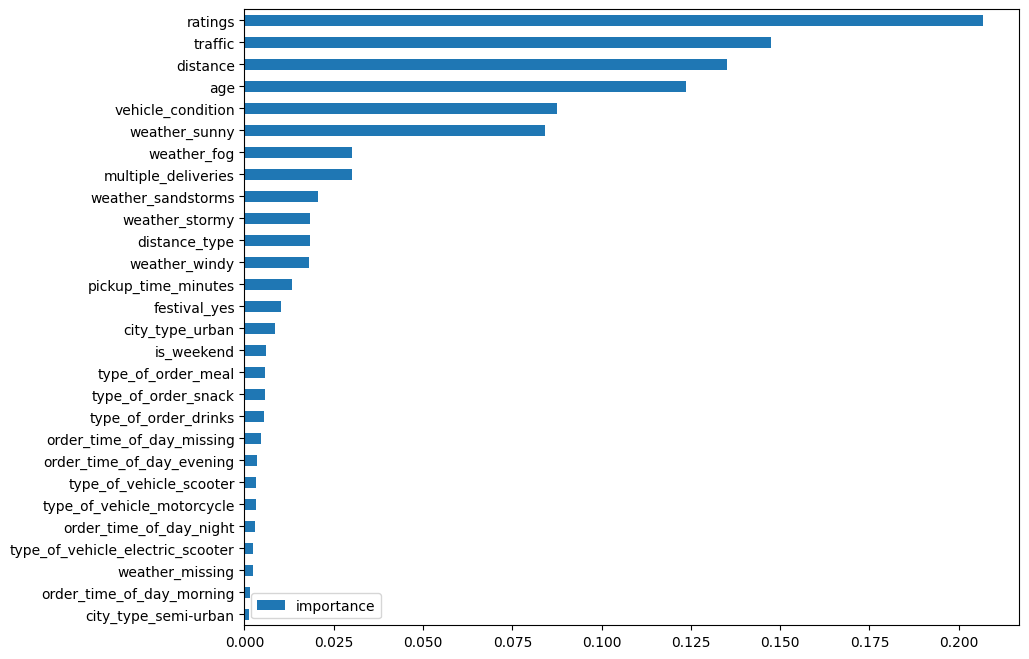

In [330]:
pd.DataFrame(
    rf.feature_importances_,
    index=model_pipe_imputed.regressor_.named_steps['preprocessing'].get_feature_names_out(),
    columns=['importance']
).sort_values(by='importance').plot(kind='barh',figsize=(10,8))